# Narrative Shift Detection Pipeline 1.5
## Group-Based Temporal Segmentation with TCL

**Key Innovation:**
- Day-level pooling → Group-level pooling → Window creation
- Two grouping strategies (one active, one commented)
- Drift detection with topic-wise visualization

**Pipeline:**
1. Load data & parse embeddings
2. Day-level aggregation (mean pooling per date)
3. Group creation (Approach 1 OR Approach 2)
4. Window creation from groups
5. TCL training
6. Drift detection & visualization
7. Model evaluation

---
# Stage 0: Environment Setup

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import json
import os
from datetime import datetime, timedelta
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

# Sklearn
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import classification_report

print("✅ Libraries imported")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

✅ Libraries imported
PyTorch version: 2.9.0+cpu
CUDA available: False


---
# Stage 1: Configuration

In [35]:
class Config:
    """Configuration for Pipeline 1.5 - Group-based Segmentation"""
    
    # ==================== DATA PATHS ====================
    DATA_PATH = '/kaggle/input/datasets/prateek1005/pipline-1-w5'  # Kaggle path
    # DATA_PATH = './DATA/Processed_Data/Topic_Wise_w5'  # Local path
    
    OUTPUT_PATH = '/kaggle/working'  # Kaggle
    # OUTPUT_PATH = './Model_output/Pipeline_1.5'  # Local
    
    TOPIC_FILES = {
        'War': 'War.csv',
        'Health': 'Health.csv',
        'Economics': 'Economics.csv',
        'Technology': 'Technology.csv',
        'Climate': 'Climate.csv'
    }
    
    TOPICS = ['War', 'Health', 'Economics', 'Technology', 'Climate']
    
    # ==================== EMBEDDING CONFIG ====================
    EMBEDDING_TYPE = 'w5_embedding'  # W5: window-5 SBERT embeddings
    EMBEDDING_DIM = 768  # SBERT all-mpnet-base-v2 dimension
    
    # ==================== GROUP SEGMENTATION PARAMETERS ====================
    # APPROACH 1: Fixed Group Size (by number of days)
    USE_FIXED_GROUP_SIZE = False  # Set to True for Approach 1
    FIXED_GROUP_SIZE = 3  # Number of days per group
    
    # APPROACH 2: Max Day Gap (by time difference)
    USE_MAX_DAY_GAP = True  # Set to True for Approach 2 (comment out Approach 1)
    MAX_DAY_GAP = 3  # Maximum days between first and last day in group
    
    # ==================== WINDOW PARAMETERS ====================
    WINDOW_SIZE = 3  # Number of GROUPS per window (not days!)
    WINDOW_STRIDE = 3  # Sliding window stride
    
    # ==================== DATA QUALITY ====================
    MIN_SENTENCES_PER_DAY = 2  # Minimum sentences required per day
    MIN_DAYS_PER_GROUP = 1  # Minimum days required per group
    
    # ==================== MODEL ARCHITECTURE ====================
    HIDDEN_DIM = 256
    NUM_HEADS = 8
    NUM_LAYERS = 3
    FEED_FORWARD_DIM = 512
    DROPOUT = 0.1
    PROJECTION_DIM = 128
    OUTPUT_DIM = 128
    
    # Feature dimensions
    TOPIC_DIM = len(TOPICS)  # 5
    TIME_DIM = 1
    FINAL_DIM = EMBEDDING_DIM + TIME_DIM + TOPIC_DIM  # 768 + 1 + 5 = 774
    
    # ==================== TRAINING ====================
    BATCH_SIZE = 32
    LEARNING_RATE = 1e-4
    EPOCHS = 100
    WARMUP_EPOCHS = 5
    MIN_LR = 1e-6
    WEIGHT_DECAY = 0.01
    TEMPERATURE = 0.07
    
    # ==================== TRAINING STABILITY ====================
    USE_AMP = True
    GRADIENT_CLIP = 1.0
    PATIENCE = 15
    MIN_DELTA = 0.001
    SAVE_CHECKPOINTS = True
    CHECKPOINT_FREQ = 10
    
    # ==================== DRIFT DETECTION ====================
    DRIFT_SMOOTHING_WINDOW = 3
    ZSCORE_THRESHOLD = 2.0
    PERCENTILE_THRESHOLD = 90
    
    # ==================== DEVICE ====================
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'


config = Config()
os.makedirs(config.OUTPUT_PATH, exist_ok=True)

print("\n" + "="*60)
print("PIPELINE 1.5 - GROUP-BASED SEGMENTATION")
print("="*60)
print(f"\n📊 Grouping Strategy:")
if config.USE_FIXED_GROUP_SIZE:
    print(f"   ✅ APPROACH 1: Fixed Group Size = {config.FIXED_GROUP_SIZE} days")
elif config.USE_MAX_DAY_GAP:
    print(f"   ✅ APPROACH 2: Max Day Gap = {config.MAX_DAY_GAP} days")
else:
    print("   ⚠️  No approach selected! Please enable one.")
    
print(f"\n🪟 Window Parameters:")
print(f"   Window Size: {config.WINDOW_SIZE} groups")
print(f"   Window Stride: {config.WINDOW_STRIDE}")
print(f"\n💾 Output: {config.OUTPUT_PATH}")
print(f"🖥️  Device: {config.DEVICE}")
print("="*60)


PIPELINE 1.5 - GROUP-BASED SEGMENTATION

📊 Grouping Strategy:
   ✅ APPROACH 2: Max Day Gap = 3 days

🪟 Window Parameters:
   Window Size: 3 groups
   Window Stride: 3

💾 Output: /kaggle/working
🖥️  Device: cpu


---
# Stage 2: Data Loading & Embedding Parsing

In [8]:
def parse_embedding(emb_str, embedding_dim):
    """
    Parse embedding string and apply L2 normalization.
    
    Args:
        emb_str: String representation of embedding (comma-separated values)
        embedding_dim: Expected embedding dimension (768)
    
    Returns:
        L2 normalized numpy array (768,)
    """
    try:
        # Method 1: Fast parsing with NumPy (for comma-separated strings)
        clean_str = str(emb_str).strip('[]"\' ')
        embedding = np.fromstring(clean_str, sep=',', dtype=np.float32)
        
        # Fallback to ast.literal_eval if needed
        if embedding.shape[0] != embedding_dim:
            embedding = np.array(ast.literal_eval(emb_str), dtype=np.float32)
        
        # Validate dimension
        if embedding.shape[0] != embedding_dim:
            return None
        
        # CRITICAL: L2 normalization
        norm = np.linalg.norm(embedding)
        if norm > 1e-8:
            embedding = embedding / norm
        
        return embedding
    
    except Exception as e:
        return None


def load_and_parse_data(config):
    """
    Load all topic CSVs and parse W5 embeddings with L2 normalization.
    Returns: Combined DataFrame with parsed embeddings
    """
    all_data = []
    
    print("\nLoading topic datasets...")
    print(f"Embedding type: {config.EMBEDDING_TYPE}")
    print(f"Embedding dimension: {config.EMBEDDING_DIM}")
    
    for topic_name, filename in config.TOPIC_FILES.items():
        filepath = os.path.join(config.DATA_PATH, filename)
        
        if not os.path.exists(filepath):
            print(f"\n  ⚠️  WARNING: {filepath} not found!")
            continue
        
        print(f"\n  Loading: {topic_name}")
        df = pd.read_csv(filepath)
        initial_count = len(df)
        
        # Add topic column
        df['topic'] = topic_name
        
        # Parse date (normalize to remove time component)
        df['date'] = pd.to_datetime(df['date'], format='ISO8601', errors='coerce').dt.normalize()
        
        # Remove rows with invalid dates
        if df['date'].isna().any():
            invalid_count = df['date'].isna().sum()
            print(f"    Removed {invalid_count} rows with invalid dates")
            df = df.dropna(subset=['date'])
        
        # Parse W5 embeddings with progress bar
        print(f"    Parsing {config.EMBEDDING_TYPE}...")
        
        embeddings = []
        valid_indices = []
        
        for idx, emb_str in tqdm(enumerate(df[config.EMBEDDING_TYPE]), 
                                  desc=f"    {topic_name}", 
                                  total=len(df), 
                                  leave=False):
            emb = parse_embedding(emb_str, config.EMBEDDING_DIM)
            if emb is not None:
                embeddings.append(emb)
                valid_indices.append(idx)
        
        # Filter valid rows
        df = df.iloc[valid_indices].copy()
        df['embedding'] = embeddings
        
        # Sort by date
        df = df.sort_values('date').reset_index(drop=True)
        
        filtered_count = len(df)
        filtered_pct = (initial_count - filtered_count) / initial_count * 100 if initial_count > 0 else 0
        
        print(f"    ✅ {filtered_count:,}/{initial_count:,} sentences loaded ({filtered_pct:.1f}% filtered)")
        print(f"    Date range: {df['date'].min().date()} → {df['date'].max().date()}")
        print(f"    Unique days: {df['date'].nunique()}")
        
        all_data.append(df)
    
    # Combine all topics
    if len(all_data) == 0:
        print("\n⚠️  ERROR: No data loaded! Check file paths and embedding format.")
        return pd.DataFrame()
    
    combined_df = pd.concat(all_data, ignore_index=True)
    
    # Remove duplicates
    before_dedup = len(combined_df)
    combined_df = combined_df.drop_duplicates(subset=['sentence_id'])
    after_dedup = len(combined_df)
    
    if before_dedup > after_dedup:
        print(f"\n  Removed {before_dedup - after_dedup:,} duplicate sentences")
    
    print(f"\n{'='*60}")
    print(f"✅ Total sentences loaded: {len(combined_df):,}")
    print(f"   Total unique days: {combined_df['date'].nunique():,}")
    print(f"   Date range: {combined_df['date'].min().date()} → {combined_df['date'].max().date()}")
    print(f"{'='*60}")
    
    return combined_df


# Load data
df = load_and_parse_data(config)

if len(df) > 0:
    print(f"\n📊 Data Summary:")
    print(f"   DataFrame shape: {df.shape}")
    print(f"   Topics distribution:")
    for topic, count in df['topic'].value_counts().items():
        print(f"      {topic:<15}: {count:,} sentences")
else:
    print("\n⚠️  ERROR: No data loaded! Please check:")
    print("   1. DATA_PATH is correct")
    print("   2. CSV files exist in the path")
    print("   3. CSV files have 'w5_embedding' column")
    print("   4. Embeddings are in correct format (comma-separated values)")


Loading topic datasets...
Embedding type: w5_embedding
Embedding dimension: 768

  Loading: War
    Parsing w5_embedding...


    ✅ 598,527/598,527 sentences loaded (0.0% filtered)
    Date range: 2011-09-19 → 2026-01-15
    Unique days: 3452

  Loading: Health
    Parsing w5_embedding...


    ✅ 144,841/144,841 sentences loaded (0.0% filtered)
    Date range: 2011-10-01 → 2026-01-15
    Unique days: 1728

  Loading: Economics
    Parsing w5_embedding...


    ✅ 84,826/84,826 sentences loaded (0.0% filtered)
    Date range: 2011-09-26 → 2025-10-21
    Unique days: 215

  Loading: Technology
    Parsing w5_embedding...


    ✅ 138,202/138,202 sentences loaded (0.0% filtered)
    Date range: 2011-10-05 → 2026-01-15
    Unique days: 1302

  Loading: Climate
    Parsing w5_embedding...


    ✅ 179,681/179,681 sentences loaded (0.0% filtered)
    Date range: 2011-09-20 → 2026-01-15
    Unique days: 1611

  Removed 209,465 duplicate sentences

✅ Total sentences loaded: 936,612
   Total unique days: 3,604
   Date range: 2011-09-19 → 2026-01-15

📊 Data Summary:
   DataFrame shape: (936612, 11)
   Topics distribution:
      War            : 598,527 sentences
      Health         : 112,520 sentences
      Climate        : 93,074 sentences
      Technology     : 93,072 sentences
      Economics      : 39,419 sentences


---
# Stage 3: Day-Level Pooling

In [9]:
def create_day_level_pools(df, config):
    """
    Pool all sentences from the same date (day-level aggregation).
    Returns: Dictionary of {topic: list of day_pools}
    """
    print("\nCreating day-level pools...")
    
    topic_day_pools = {}
    
    for topic_name in config.TOPICS:
        print(f"\n  Topic: {topic_name}")
        
        # Filter topic data
        topic_df = df[df['topic'] == topic_name].copy()
        
        # Group by date
        day_pools = []
        
        for date, group in topic_df.groupby('date'):
            if len(group) >= config.MIN_SENTENCES_PER_DAY:
                # Mean pool embeddings for this day
                embeddings = np.stack(group['embedding'].values)
                mean_embedding = embeddings.mean(axis=0)
                
                # Get topic scores (mean)
                topic_scores = group[config.TOPICS].mean().values
                
                day_pools.append({
                    'date': date,
                    'embedding': mean_embedding,
                    'topic_scores': topic_scores,
                    'num_sentences': len(group)
                })
        
        # Sort by date
        day_pools = sorted(day_pools, key=lambda x: x['date'])
        
        topic_day_pools[topic_name] = day_pools
        
        print(f"    Days: {len(day_pools)}")
        print(f"    Date range: {day_pools[0]['date'].date()} → {day_pools[-1]['date'].date()}")
    
    print(f"\n{'='*60}")
    print("✅ Day-level pooling complete")
    print(f"{'='*60}")
    
    return topic_day_pools


# Create day pools
topic_day_pools = create_day_level_pools(df, config)


Creating day-level pools...

  Topic: War
    Days: 3302
    Date range: 2011-09-19 → 2026-01-15

  Topic: Health
    Days: 1339
    Date range: 2011-10-14 → 2026-01-15

  Topic: Economics
    Days: 152
    Date range: 2011-09-26 → 2025-10-21

  Topic: Technology
    Days: 800
    Date range: 2011-10-05 → 2026-01-15

  Topic: Climate
    Days: 1132
    Date range: 2011-09-21 → 2026-01-15

✅ Day-level pooling complete


---
# Stage 4: Group Creation

**Two Approaches (one active, one commented):**
- **Approach 1:** Fixed group size (by number of days)
- **Approach 2:** Max day gap (by time difference)

In [36]:
# ============================================================
# APPROACH 1: Fixed Group Size (Number of Days)
# ============================================================

def create_groups_fixed_size(day_pools, group_size):
    """
    Create groups of fixed size (by number of days).
    
    Example: group_size=3, days=[2,3,5,6,8,9]
    → Groups: G1=[2,3,5], G2=[6,8,9]
    
    Returns: List of groups (each group is a dict with pooled embedding)
    """
    groups = []
    
    # Create fixed-size groups
    for i in range(0, len(day_pools), group_size):
        group_days = day_pools[i:i+group_size]
        
        if len(group_days) >= 1:  # At least 1 day
            # Mean pool all days in this group
            group_embeddings = np.stack([d['embedding'] for d in group_days])
            mean_embedding = group_embeddings.mean(axis=0)
            
            # Mean pool topic scores
            topic_scores = np.stack([d['topic_scores'] for d in group_days]).mean(axis=0)
            
            # Group start date (earliest date in group)
            start_date = group_days[0]['date']
            end_date = group_days[-1]['date']
            
            groups.append({
                'group_id': len(groups),
                'start_date': start_date,
                'end_date': end_date,
                'num_days': len(group_days),
                'embedding': mean_embedding,
                'topic_scores': topic_scores,
                'dates': [d['date'] for d in group_days]
            })
    
    return groups


# ============================================================
# APPROACH 2: Max Day Gap (Time Difference)
# ============================================================

def create_groups_max_gap(day_pools, max_gap_days):
    """
    Create groups where max time difference ≤ max_gap_days.
    
    Example: max_gap=3, days=[2,3,5,6,8,9,10]
    → Groups: G1=[2,3] (5 would make gap=3, excluded)
              G2=[5,6]
              G3=[8,9,10]
    
    Returns: List of groups
    """
    groups = []
    current_group = []
    
    for day_pool in day_pools:
        if len(current_group) == 0:
            # Start new group
            current_group.append(day_pool)
        else:
            # Check if adding this day exceeds max gap
            first_date = current_group[0]['date']
            current_date = day_pool['date']
            gap = (current_date - first_date).days
            
            if gap <= max_gap_days:
                # Add to current group
                current_group.append(day_pool)
            else:
                # Save current group and start new one
                if len(current_group) >= 1:
                    groups.append(current_group)
                current_group = [day_pool]
    
    # Add last group
    if len(current_group) >= 1:
        groups.append(current_group)
    
    # Convert to group dictionaries
    formatted_groups = []
    for group_days in groups:
        # Mean pool embeddings
        group_embeddings = np.stack([d['embedding'] for d in group_days])
        mean_embedding = group_embeddings.mean(axis=0)
        
        # Mean pool topic scores
        topic_scores = np.stack([d['topic_scores'] for d in group_days]).mean(axis=0)
        
        formatted_groups.append({
            'group_id': len(formatted_groups),
            'start_date': group_days[0]['date'],
            'end_date': group_days[-1]['date'],
            'num_days': len(group_days),
            'embedding': mean_embedding,
            'topic_scores': topic_scores,
            'dates': [d['date'] for d in group_days]
        })
    
    return formatted_groups


# ============================================================
# CREATE GROUPS (Select Approach)
# ============================================================

def create_topic_groups(topic_day_pools, config):
    """
    Create groups for all topics using selected approach.
    """
    print("\nCreating groups...")
    
    topic_groups = {}
    
    for topic_name in config.TOPICS:
        day_pools = topic_day_pools[topic_name]
        
        print(f"\n  Topic: {topic_name}")
        print(f"    Input days: {len(day_pools)}")
        
        # Select approach
        if config.USE_FIXED_GROUP_SIZE:
            groups = create_groups_fixed_size(day_pools, config.FIXED_GROUP_SIZE)
            print(f"    Strategy: Fixed size ({config.FIXED_GROUP_SIZE} days/group)")
        
        elif config.USE_MAX_DAY_GAP:
            groups = create_groups_max_gap(day_pools, config.MAX_DAY_GAP)
            print(f"    Strategy: Max gap ({config.MAX_DAY_GAP} days)")
        
        else:
            raise ValueError("No grouping strategy selected!")
        
        topic_groups[topic_name] = groups
        
        print(f"    Output groups: {len(groups)}")
        if len(groups) > 0:
            print(f"    Group size range: {min(g['num_days'] for g in groups)}-{max(g['num_days'] for g in groups)} days")
            print(f"    Example groups:")
            for g in groups[:3]:
                dates_str = ', '.join([d.strftime('%Y-%m-%d') for d in g['dates']])
                print(f"      G{g['group_id']}: [{dates_str}]")
    
    print(f"\n{'='*60}")
    print("✅ Group creation complete")
    print(f"{'='*60}")
    
    return topic_groups


# Create groups
topic_groups = create_topic_groups(topic_day_pools, config)


Creating groups...

  Topic: War
    Input days: 3302
    Strategy: Max gap (3 days)
    Output groups: 967
    Group size range: 1-4 days
    Example groups:
      G0: [2011-09-19, 2011-09-21, 2011-09-22]
      G1: [2011-09-26, 2011-09-27, 2011-09-28, 2011-09-29]
      G2: [2011-09-30, 2011-10-03]

  Topic: Health
    Input days: 1339
    Strategy: Max gap (3 days)
    Output groups: 564
    Group size range: 1-4 days
    Example groups:
      G0: [2011-10-14]
      G1: [2011-10-29]
      G2: [2011-12-09]

  Topic: Economics
    Input days: 152
    Strategy: Max gap (3 days)
    Output groups: 66
    Group size range: 1-4 days
    Example groups:
      G0: [2011-09-26, 2011-09-28]
      G1: [2011-10-04, 2011-10-05]
      G2: [2011-10-10]

  Topic: Technology
    Input days: 800
    Strategy: Max gap (3 days)
    Output groups: 430
    Group size range: 1-4 days
    Example groups:
      G0: [2011-10-05]
      G1: [2011-10-18]
      G2: [2011-10-24]

  Topic: Climate
    Input days: 1

---
# Stage 5: Window Creation from Groups

In [37]:
def create_windows_from_groups(topic_groups, config):
    """
    Create sliding windows from groups.
    Window = [G1, G2, G3] instead of [Day1, Day2, Day3]
    
    Returns: Dictionary of {topic: list of windows}
    """
    print("\nCreating windows from groups...")
    
    topic_windows = {}
    
    for topic_name in config.TOPICS:
        groups = topic_groups[topic_name]
        
        print(f"\n  Topic: {topic_name}")
        print(f"    Input groups: {len(groups)}")
        
        windows = []
        
        # Create sliding windows
        for i in range(0, len(groups) - config.WINDOW_SIZE + 1, config.WINDOW_STRIDE):
            window_groups = groups[i:i+config.WINDOW_SIZE]
            
            # Build feature tensor for this window
            window_features = []
            
            # Reference time (first group's start date)
            ref_time = window_groups[0]['start_date']
            
            for group in window_groups:
                # Time delta (days since reference)
                time_delta = (group['start_date'] - ref_time).days
                time_feature = np.array([time_delta], dtype=np.float32)
                
                # Concatenate: [embedding(768) + time(1) + topics(5)]
                features = np.concatenate([
                    group['embedding'],
                    time_feature,
                    group['topic_scores']
                ])
                
                window_features.append(features)
            
            # Stack to tensor (window_size, 774)
            window_tensor = np.stack(window_features)
            
            windows.append({
                'window_idx': len(windows),
                'start_date': window_groups[0]['start_date'],
                'end_date': window_groups[-1]['end_date'],
                'group_ids': [g['group_id'] for g in window_groups],
                'tensor': window_tensor,
                'topic': topic_name
            })
        
        topic_windows[topic_name] = windows
        
        print(f"    Output windows: {len(windows)}")
        if len(windows) > 0:
            print(f"    Window shape: {windows[0]['tensor'].shape}")
            print(f"    Date range: {windows[0]['start_date'].date()} → {windows[-1]['end_date'].date()}")
    
    print(f"\n{'='*60}")
    print("✅ Window creation complete")
    print(f"{'='*60}")
    
    return topic_windows


# Create windows
topic_windows = create_windows_from_groups(topic_groups, config)

# Show statistics
total_windows = sum(len(windows) for windows in topic_windows.values())
print(f"\n📊 Total windows across all topics: {total_windows:,}")


Creating windows from groups...

  Topic: War
    Input groups: 967
    Output windows: 322
    Window shape: (3, 774)
    Date range: 2011-09-19 → 2025-12-25

  Topic: Health
    Input groups: 564
    Output windows: 188
    Window shape: (3, 774)
    Date range: 2011-10-14 → 2026-01-15

  Topic: Economics
    Input groups: 66
    Output windows: 22
    Window shape: (3, 774)
    Date range: 2011-09-26 → 2025-10-21

  Topic: Technology
    Input groups: 430
    Output windows: 143
    Window shape: (3, 774)
    Date range: 2011-10-05 → 2026-01-10

  Topic: Climate
    Input groups: 538
    Output windows: 179
    Window shape: (3, 774)
    Date range: 2011-09-21 → 2025-12-25

✅ Window creation complete

📊 Total windows across all topics: 854


---
# Stage 6: TCL Model Architecture

In [38]:
class ImprovedTemporalEncoder(nn.Module):
    """
    Enhanced Transformer-based temporal encoder for narrative shift detection.
    
    STABILITY IMPROVEMENTS:
    1. Input LayerNorm before projection
    2. Dropout after input projection
    3. GELU activation
    4. Pre-layer normalization (norm_first=True)
    5. Residual post-MLP after pooling
    6. Attention pooling instead of mean pooling
    """
    
    def __init__(self, config):
        super().__init__()
        
        self.config = config
        
        # IMPROVEMENT 1: Input LayerNorm
        self.input_norm = nn.LayerNorm(config.FINAL_DIM)
        
        # Input projection
        self.input_proj = nn.Linear(config.FINAL_DIM, config.HIDDEN_DIM)
        
        # IMPROVEMENT 2: Dropout after projection
        self.dropout = nn.Dropout(config.DROPOUT)
        
        # Learnable positional encoding
        self.pos_encoding_learned = nn.Parameter(
            torch.randn(1, config.WINDOW_SIZE, config.HIDDEN_DIM) * 0.02
        )
        
        # Sinusoidal positional encoding
        self.register_buffer('pos_encoding_sinusoidal', 
                            self._create_sinusoidal_positions(config.WINDOW_SIZE, config.HIDDEN_DIM))
        
        # Temporal decay attention
        self.temporal_decay = nn.Parameter(torch.ones(1, config.WINDOW_SIZE, 1) * 0.1)
        
        # IMPROVEMENT 3 & 4: Enhanced Transformer with GELU and pre-layer norm
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=config.HIDDEN_DIM,
            nhead=config.NUM_HEADS,
            dim_feedforward=config.FEED_FORWARD_DIM,
            dropout=config.DROPOUT,
            activation='gelu',
            batch_first=True,
            norm_first=True
        )
        
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=config.NUM_LAYERS,
            norm=nn.LayerNorm(config.HIDDEN_DIM)
        )
        
        # Attention-based pooling
        self.attention_query = nn.Parameter(torch.randn(1, 1, config.HIDDEN_DIM) * 0.02)
        self.attention_score = nn.Linear(config.HIDDEN_DIM, 1)
        
        # IMPROVEMENT 5: Post-MLP for residual connection
        self.post_mlp = nn.Sequential(
            nn.Linear(config.HIDDEN_DIM, config.HIDDEN_DIM),
            nn.GELU(),
            nn.Dropout(config.DROPOUT),
            nn.Linear(config.HIDDEN_DIM, config.HIDDEN_DIM)
        )
        
        # Projection head
        self.projection_head = nn.Sequential(
            nn.Linear(config.HIDDEN_DIM, config.PROJECTION_DIM),
            nn.LayerNorm(config.PROJECTION_DIM),
            nn.GELU(),
            nn.Dropout(config.DROPOUT),
            nn.Linear(config.PROJECTION_DIM, config.OUTPUT_DIM)
        )
        
        self._init_weights()
    
    def _create_sinusoidal_positions(self, length, dim):
        """Create sinusoidal positional encodings"""
        position = torch.arange(length).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, dim, 2).float() * (-np.log(10000.0) / dim))
        
        pos_enc = torch.zeros(1, length, dim)
        pos_enc[0, :, 0::2] = torch.sin(position * div_term)
        pos_enc[0, :, 1::2] = torch.cos(position * div_term)
        
        return pos_enc
    
    def _init_weights(self):
        """Initialize weights with Xavier/He initialization"""
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.constant_(module.bias, 0)
            elif isinstance(module, nn.LayerNorm):
                nn.init.constant_(module.weight, 1)
                nn.init.constant_(module.bias, 0)
    
    def forward(self, x, return_features=False):
        """
        Args:
            x: (batch, window_size, 774) - Input windows
            return_features: If True, return intermediate features
        
        Returns:
            z: (batch, 128) - L2 normalized final embeddings
        """
        # Input LayerNorm
        x = self.input_norm(x)
        
        # Input projection
        x = self.input_proj(x)
        x = self.dropout(x)
        
        # Add positional encodings
        x = x + self.pos_encoding_learned + self.pos_encoding_sinusoidal
        
        # Apply temporal decay weighting
        temporal_weights = torch.sigmoid(self.temporal_decay)
        x = x * temporal_weights
        
        # Transformer encoding
        encoded = self.transformer(x)
        
        # Attention-based pooling
        attention_scores = self.attention_score(encoded)
        attention_weights = F.softmax(attention_scores, dim=1)
        features = (encoded * attention_weights).sum(dim=1)
        
        # Residual post-MLP
        features = features + self.post_mlp(features)
        
        # Project to final dimension
        projected = self.projection_head(features)
        
        # L2 normalization
        z = F.normalize(projected, p=2, dim=1)
        
        if return_features:
            return z, features, attention_weights
        return z


class EnhancedNTXentLoss(nn.Module):
    """
    Enhanced Normalized Temperature-scaled Cross Entropy Loss.
    
    Improvements:
    - Numerical stability
    - Mixed precision compatible
    """
    
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature
    
    def forward(self, z_i, z_j):
        """
        Args:
            z_i: Anchor embeddings (B, D)
            z_j: Positive embeddings (B, D)
        
        Returns:
            loss: Scalar contrastive loss
        """
        batch_size = z_i.shape[0]
        device = z_i.device
        
        # Concatenate anchors and positives
        z = torch.cat([z_i, z_j], dim=0)
        
        # Normalize embeddings
        z = F.normalize(z, p=2, dim=1)
        
        # Compute similarity matrix
        sim_matrix = torch.mm(z, z.t()) / self.temperature
        
        # Numerical stability
        sim_matrix_max = sim_matrix.max(dim=1, keepdim=True)[0].detach()
        sim_matrix = sim_matrix - sim_matrix_max
        
        # Create labels
        labels = torch.arange(2 * batch_size, device=device)
        labels = (labels + batch_size) % (2 * batch_size)
        
        # Mask out self-similarities
        mask = torch.eye(2 * batch_size, dtype=torch.bool, device=device)
        sim_matrix = sim_matrix.masked_fill(mask, -1e4)
        
        # Cross entropy loss
        loss = F.cross_entropy(sim_matrix, labels)
        
        return loss


# Initialize model
device = torch.device(config.DEVICE)
model = ImprovedTemporalEncoder(config).to(device)
criterion = EnhancedNTXentLoss(temperature=config.TEMPERATURE)

print("\n" + "="*60)
print("IMPROVED MODEL ARCHITECTURE - STABILITY ENHANCED")
print("="*60)
print(f"\nInput dim: {config.FINAL_DIM}")
print(f"Hidden dim: {config.HIDDEN_DIM}")
print(f"Output dim: {config.OUTPUT_DIM}")
print(f"\nParameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"\n✅ Input LayerNorm")
print(f"✅ Dropout after projection")
print(f"✅ GELU activation")
print(f"✅ Pre-layer normalization")
print(f"✅ Attention pooling")
print(f"✅ Residual post-MLP")
print("="*60)


IMPROVED MODEL ARCHITECTURE - STABILITY ENHANCED

Input dim: 774
Hidden dim: 256
Output dim: 128

Parameters: 1,964,304
Trainable: 1,964,304

✅ Input LayerNorm
✅ Dropout after projection
✅ GELU activation
✅ Pre-layer normalization
✅ Attention pooling
✅ Residual post-MLP


---
# Stage 7: Dataset & DataLoader

In [39]:
class WindowPairDataset(Dataset):
    """Dataset for window pairs (consecutive windows)"""
    
    def __init__(self, topic_windows):
        self.pairs = []
        
        # Create consecutive pairs for each topic
        for topic_name, windows in topic_windows.items():
            for i in range(len(windows) - 1):
                self.pairs.append({
                    'w1': windows[i]['tensor'],
                    'w2': windows[i+1]['tensor'],
                    'topic': topic_name
                })
    
    def __len__(self):
        return len(self.pairs)
    
    def __getitem__(self, idx):
        pair = self.pairs[idx]
        return {
            'w1': torch.from_numpy(pair['w1']).float(),
            'w2': torch.from_numpy(pair['w2']).float()
        }


# Create dataset
dataset = WindowPairDataset(topic_windows)
dataloader = DataLoader(
    dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True if config.DEVICE == 'cuda' else False
)

print(f"\n{'='*60}")
print(f"DATASET READY")
print(f"{'='*60}")
print(f"\nTotal pairs: {len(dataset):,}")
print(f"Batch size: {config.BATCH_SIZE}")
print(f"Batches per epoch: {len(dataloader):,}")
print(f"{'='*60}")


DATASET READY

Total pairs: 849
Batch size: 32
Batches per epoch: 27


---
# Stage 8: Training Loop

In [40]:
def train_model(model, dataloader, criterion, config, device):
    """
    Train TCL model with ALL stability improvements:
    1. Gradient clipping
    2. Cosine learning rate scheduler with warmup
    3. Mixed precision training (AMP)
    4. Early stopping with patience
    5. Model checkpointing
    """
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config.LEARNING_RATE,
        weight_decay=config.WEIGHT_DECAY,
        betas=(0.9, 0.999),
        eps=1e-8
    )
    
    # Cosine annealing with warmup
    def lr_lambda(epoch):
        if epoch < config.WARMUP_EPOCHS:
            return (epoch + 1) / config.WARMUP_EPOCHS
        else:
            progress = (epoch - config.WARMUP_EPOCHS) / max(1, config.EPOCHS - config.WARMUP_EPOCHS)
            return max(config.MIN_LR / config.LEARNING_RATE, 0.5 * (1 + np.cos(np.pi * progress)))
    
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)
    
    # Mixed precision training
    scaler = torch.cuda.amp.GradScaler() if config.USE_AMP and config.DEVICE == 'cuda' else None
    
    # Training history
    history = {'loss': [], 'lr': []}
    best_loss = float('inf')
    patience_counter = 0
    
    print("\n" + "="*60)
    print("TRAINING START - ENHANCED STABILITY")
    print("="*60)
    if scaler:
        print("✅ Mixed Precision Training (AMP) enabled")
    print(f"✅ Gradient clipping: {config.GRADIENT_CLIP}")
    print(f"✅ Early stopping patience: {config.PATIENCE}")
    print(f"✅ Cosine LR scheduler with warmup")
    print("="*60 + "\n")
    
    for epoch in range(config.EPOCHS):
        model.train()
        epoch_loss = 0.0
        
        pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{config.EPOCHS}")
        
        for batch in pbar:
            w1 = batch['w1'].to(device)
            w2 = batch['w2'].to(device)
            
            optimizer.zero_grad()
            
            # Forward pass with AMP
            if scaler:
                with torch.cuda.amp.autocast():
                    z1 = model(w1)
                    z2 = model(w2)
                    loss = criterion(z1, z2)
                
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), config.GRADIENT_CLIP)
                scaler.step(optimizer)
                scaler.update()
            else:
                z1 = model(w1)
                z2 = model(w2)
                loss = criterion(z1, z2)
                
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), config.GRADIENT_CLIP)
                optimizer.step()
            
            epoch_loss += loss.item()
            pbar.set_postfix({'loss': f'{loss.item():.4f}', 'lr': f'{optimizer.param_groups[0]["lr"]:.2e}'})
        
        # Epoch stats
        avg_loss = epoch_loss / len(dataloader)
        current_lr = optimizer.param_groups[0]['lr']
        
        history['loss'].append(avg_loss)
        history['lr'].append(current_lr)
        
        print(f"  Epoch {epoch+1}: Loss = {avg_loss:.4f}, LR = {current_lr:.2e}")
        
        # Early stopping check
        if avg_loss < best_loss - config.MIN_DELTA:
            best_loss = avg_loss
            patience_counter = 0
            # Save best model
            torch.save(model.state_dict(), os.path.join(config.OUTPUT_PATH, 'best_model.pt'))
            print(f"  ✅ Best model saved (loss: {best_loss:.4f})")
        else:
            patience_counter += 1
        
        # Checkpoint saving
        if config.SAVE_CHECKPOINTS and (epoch + 1) % config.CHECKPOINT_FREQ == 0:
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': avg_loss
            }, os.path.join(config.OUTPUT_PATH, f'checkpoint_epoch_{epoch+1}.pt'))
        
        # Early stopping
        if patience_counter >= config.PATIENCE:
            print(f"\n⚠️  Early stopping triggered at epoch {epoch+1}")
            break
        
        scheduler.step()
    
    print("\n" + "="*60)
    print("TRAINING COMPLETE")
    print("="*60)
    print(f"Best loss: {best_loss:.4f}")
    print(f"Final loss: {history['loss'][-1]:.4f}")
    
    return history


# Train model
history = train_model(model, dataloader, criterion, config, device)

# Save final model
torch.save(model.state_dict(), os.path.join(config.OUTPUT_PATH, 'final_model.pt'))
print(f"\n✅ Final model saved to: {config.OUTPUT_PATH}/final_model.pt")


TRAINING START - ENHANCED STABILITY
✅ Gradient clipping: 1.0
✅ Early stopping patience: 15
✅ Cosine LR scheduler with warmup



Epoch 1/100: 100%|██████████| 27/27 [00:03<00:00,  7.80it/s, loss=3.1487, lr=2.00e-05]


  Epoch 1: Loss = 4.0183, LR = 2.00e-05
  ✅ Best model saved (loss: 4.0183)


Epoch 2/100: 100%|██████████| 27/27 [00:03<00:00,  7.58it/s, loss=3.3836, lr=4.00e-05]


  Epoch 2: Loss = 3.5371, LR = 4.00e-05
  ✅ Best model saved (loss: 3.5371)


...

  Epoch 88: Loss = 0.6372, LR = 4.55e-06


Epoch 89/100: 100%|██████████| 27/27 [00:03<00:00,  7.76it/s, loss=0.5867, lr=3.89e-06]


  Epoch 89: Loss = 0.5984, LR = 3.89e-06


Epoch 90/100: 100%|██████████| 27/27 [00:03<00:00,  7.84it/s, loss=0.2860, lr=3.27e-06]

  Epoch 90: Loss = 0.5996, LR = 3.27e-06

⚠️  Early stopping triggered at epoch 90

TRAINING COMPLETE
Best loss: 0.5808
Final loss: 0.5996

✅ Final model saved to: /kaggle/working/final_model.pt


---
# Stage 9: Training Visualization

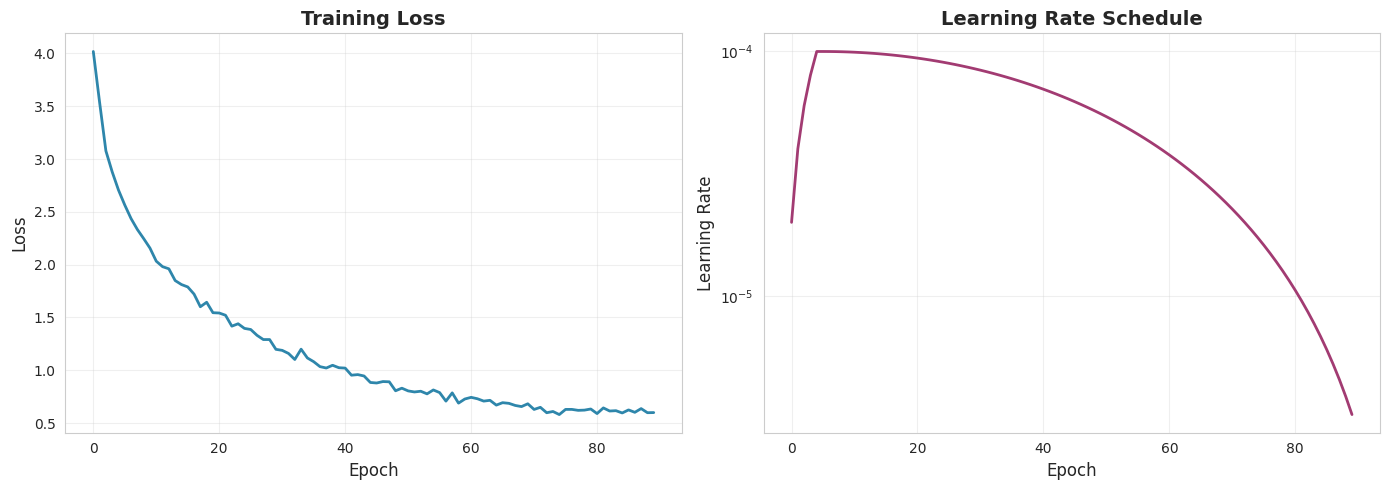


✅ Training history saved to: /kaggle/working/training_history.png


In [41]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(history['loss'], linewidth=2, color='#2E86AB')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training Loss', fontsize=14, fontweight='bold')
axes[0].grid(alpha=0.3)

# Learning rate
axes[1].plot(history['lr'], linewidth=2, color='#A23B72')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Learning Rate', fontsize=12)
axes[1].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)
axes[1].set_yscale('log')

plt.tight_layout()
plt.savefig(os.path.join(config.OUTPUT_PATH, 'training_history.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Training history saved to: {config.OUTPUT_PATH}/training_history.png")

---
# Stage 10: Model Evaluation

In [42]:
def evaluate_model_quality(model, topic_windows, device, config, n_samples=1000):
    """
    Evaluate model quality using various metrics.
    
    Metrics:
    1. Embedding quality (intra-topic vs inter-topic similarity)
    2. Temporal consistency (consecutive windows should be similar)
    3. Separation score (how well topics are separated)
    """
    print("\n" + "="*60)
    print("MODEL QUALITY EVALUATION")
    print("="*60)
    
    model.eval()
    
    # Sample windows from each topic
    topic_embeddings = {topic: [] for topic in config.TOPICS}
    topic_windows_data = {topic: [] for topic in config.TOPICS}
    
    with torch.no_grad():
        for topic_name in config.TOPICS:
            windows = topic_windows[topic_name]
            
            # Sample random windows
            n_sample = min(n_samples // len(config.TOPICS), len(windows))
            if n_sample > len(windows):
                sampled_windows = windows
            else:
                sampled_indices = np.random.choice(len(windows), size=n_sample, replace=False)
                sampled_windows = [windows[i] for i in sampled_indices]
            
            print(f"  Sampling {topic_name}: {len(sampled_windows)} windows")
            
            for window in sampled_windows:
                tensor = torch.from_numpy(window['tensor']).unsqueeze(0).float().to(device)
                z = model(tensor)
                topic_embeddings[topic_name].append(z.cpu().numpy()[0])
                topic_windows_data[topic_name].append(window)
            
            topic_embeddings[topic_name] = np.array(topic_embeddings[topic_name])
    
    # Metric 1: Intra-topic similarity (higher is better - same topic should be similar)
    print("\n📊 Metric 1: Intra-Topic Similarity (Higher = Better)")
    intra_topic_sims = {}
    
    for topic_name, embeddings in topic_embeddings.items():
        if len(embeddings) < 2:
            continue
        
        # Compute pairwise cosine similarities within topic
        sims = []
        for i in range(len(embeddings)):
            for j in range(i+1, min(i+20, len(embeddings))):  # Compare with next 20
                sim = np.dot(embeddings[i], embeddings[j])
                sims.append(sim)
        
        avg_sim = np.mean(sims)
        intra_topic_sims[topic_name] = avg_sim
        print(f"   {topic_name:<15}: {avg_sim:.4f}")
    
    # Metric 2: Inter-topic similarity (lower is better - different topics should be distinct)
    print("\n📊 Metric 2: Inter-Topic Similarity (Lower = Better Separation)")
    inter_topic_sims = {}
    
    topic_names = list(topic_embeddings.keys())
    for i, topic1 in enumerate(topic_names):
        for topic2 in topic_names[i+1:]:
            emb1 = topic_embeddings[topic1]
            emb2 = topic_embeddings[topic2]
            
            # Sample pairs
            n_pairs = min(100, len(emb1), len(emb2))
            sims = []
            
            for _ in range(n_pairs):
                idx1 = np.random.randint(0, len(emb1))
                idx2 = np.random.randint(0, len(emb2))
                sim = np.dot(emb1[idx1], emb2[idx2])
                sims.append(sim)
            
            avg_sim = np.mean(sims)
            inter_topic_sims[f"{topic1}-{topic2}"] = avg_sim
            print(f"   {topic1:<12} vs {topic2:<12}: {avg_sim:.4f}")
    
    # Metric 3: Separation Score (intra / inter ratio)
    print("\n📊 Metric 3: Separation Score (Higher = Better)")
    avg_intra = np.mean(list(intra_topic_sims.values()))
    avg_inter = np.mean(list(inter_topic_sims.values()))
    separation_score = avg_intra / (avg_inter + 1e-8)
    
    print(f"   Average Intra-Topic Similarity: {avg_intra:.4f}")
    print(f"   Average Inter-Topic Similarity: {avg_inter:.4f}")
    print(f"   Separation Score: {separation_score:.4f}")
    
    if separation_score > 1.2:
        print(f"   ✅ EXCELLENT separation (score > 1.2)")
    elif separation_score > 1.0:
        print(f"   ✅ GOOD separation (score > 1.0)")
    else:
        print(f"   ⚠️  WEAK separation (score < 1.0) - consider longer training")
    
    # Metric 4: Temporal Consistency
    print("\n📊 Metric 4: Temporal Consistency (Consecutive Windows)")
    temporal_consistencies = {}
    
    for topic_name in config.TOPICS:
        windows = sorted(topic_windows[topic_name], key=lambda x: x['window_idx'])
        
        if len(windows) < 2:
            continue
        
        # Encode consecutive windows
        consecutive_sims = []
        
        for i in range(min(100, len(windows)-1)):
            with torch.no_grad():
                tensor1 = torch.from_numpy(windows[i]['tensor']).unsqueeze(0).float().to(device)
                tensor2 = torch.from_numpy(windows[i+1]['tensor']).unsqueeze(0).float().to(device)
                
                z1 = model(tensor1).cpu().numpy()[0]
                z2 = model(tensor2).cpu().numpy()[0]
                
                sim = np.dot(z1, z2)
                consecutive_sims.append(sim)
        
        avg_consistency = np.mean(consecutive_sims)
        temporal_consistencies[topic_name] = avg_consistency
        print(f"   {topic_name:<15}: {avg_consistency:.4f}")
    
    # Summary
    print("\n" + "="*60)
    print("EVALUATION SUMMARY")
    print("="*60)
    print(f"✅ Intra-topic similarity: {avg_intra:.4f} (higher = better)")
    print(f"✅ Inter-topic similarity: {avg_inter:.4f} (lower = better)")
    print(f"✅ Separation score: {separation_score:.4f} (higher = better)")
    print(f"✅ Avg temporal consistency: {np.mean(list(temporal_consistencies.values())):.4f}")
    print("="*60)
    
    return {
        'intra_topic_sims': intra_topic_sims,
        'inter_topic_sims': inter_topic_sims,
        'separation_score': separation_score,
        'temporal_consistencies': temporal_consistencies,
        'avg_intra': avg_intra,
        'avg_inter': avg_inter
    }


# Evaluate model quality
print("\nEvaluating model quality...")
evaluation_metrics = evaluate_model_quality(model, topic_windows, device, config, n_samples=1000)


Evaluating model quality...

MODEL QUALITY EVALUATION
  Sampling War: 200 windows
  Sampling Health: 188 windows
  Sampling Economics: 22 windows
  Sampling Technology: 143 windows
  Sampling Climate: 179 windows

📊 Metric 1: Intra-Topic Similarity (Higher = Better)
   War            : 0.1706
   Health         : 0.2678
   Economics      : 0.6261
   Technology     : 0.2718
   Climate        : 0.2561

📊 Metric 2: Inter-Topic Similarity (Lower = Better Separation)
   War          vs Health      : -0.0456
   War          vs Economics   : -0.0087
   War          vs Technology  : -0.0730
   War          vs Climate     : -0.0778
   Health       vs Economics   : -0.1976
   Health       vs Technology  : -0.0489
   Health       vs Climate     : -0.0161
   Economics    vs Technology  : 0.0626
   Economics    vs Climate     : 0.0801
   Technology   vs Climate     : -0.0358

📊 Metric 3: Separation Score (Higher = Better)
   Average Intra-Topic Similarity: 0.3185
   Average Inter-Topic Similarity: 


Generating cosine similarity matrix...

COSINE SIMILARITY MATRIX VISUALIZATION

Encoding all windows by topic...
  War            : 322 windows


  Health         : 188 windows


  Economics      : 22 windows


  Technology     : 143 windows


  Climate        : 179 windows



  Total windows encoded: 854
  Embedding shape: (854, 128)

  Sorting by topics...
  Computing similarity matrix...
  Similarity matrix shape: (854, 854)

  Creating visualization...


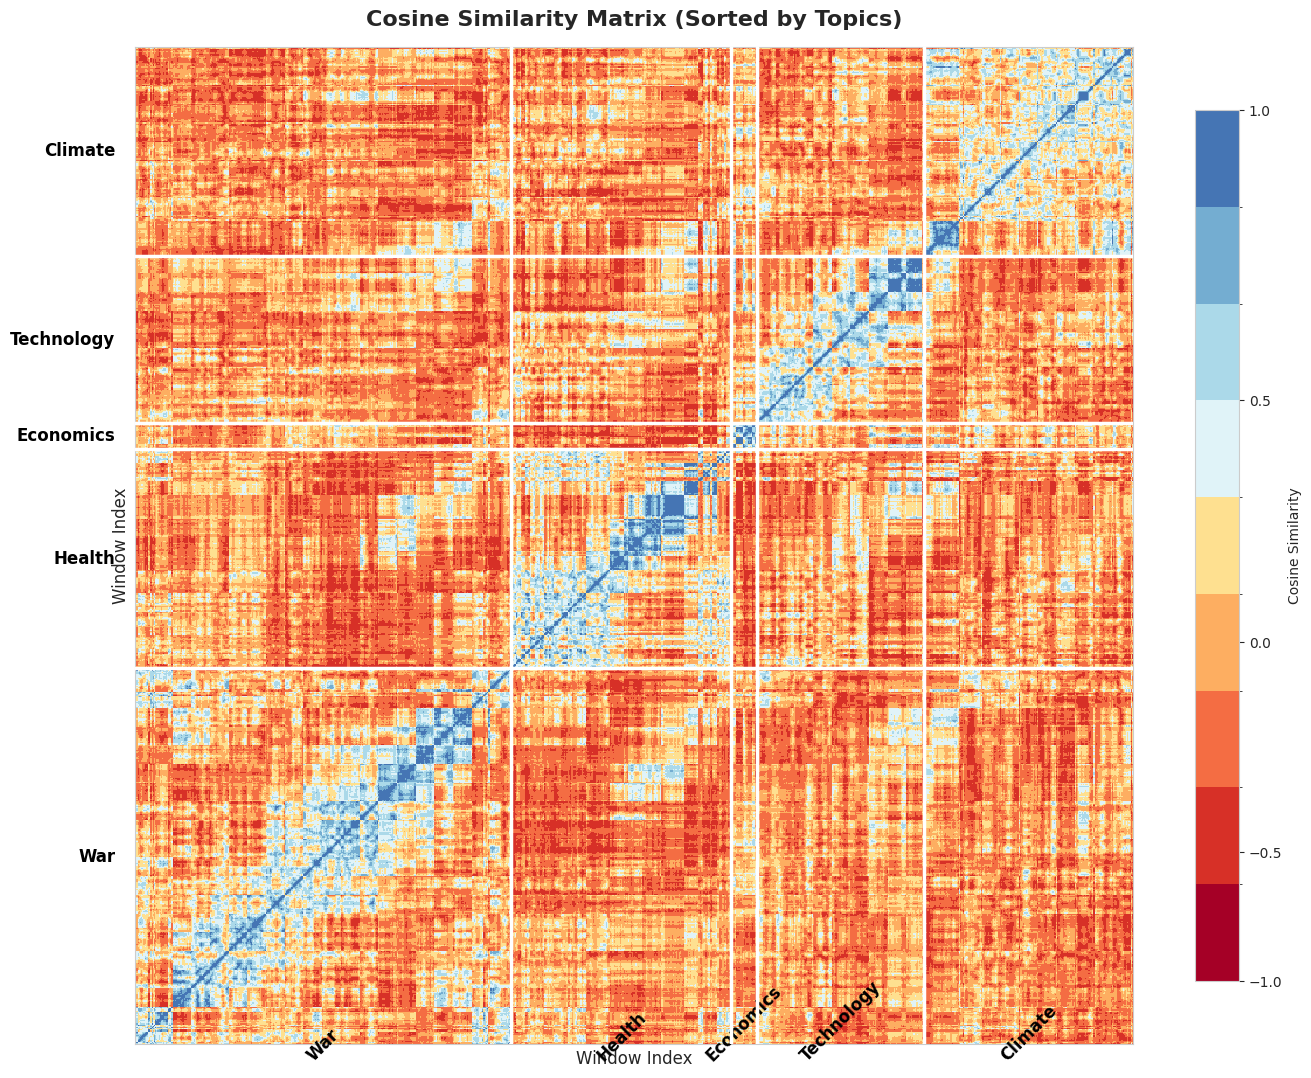


SIMILARITY MATRIX STATISTICS

📊 Intra-Topic Similarities (Same Topic):
  War            : μ = 0.1535 ± 0.3058
  Health         : μ = 0.2656 ± 0.3197
  Economics      : μ = 0.6284 ± 0.2547
  Technology     : μ = 0.2778 ± 0.3234
  Climate        : μ = 0.2591 ± 0.2613

📊 Inter-Topic Similarities (Different Topics):
  War             ↔ Health         : μ = -0.0617
  War             ↔ Economics      : μ = 0.0003
  War             ↔ Technology     : μ = -0.0389
  War             ↔ Climate        : μ = -0.0719
  Health          ↔ Economics      : μ = -0.1867
  Health          ↔ Technology     : μ = -0.0181
  Health          ↔ Climate        : μ = -0.0355
  Economics       ↔ Technology     : μ = 0.1005
  Economics       ↔ Climate        : μ = 0.0979
  Technology      ↔ Climate        : μ = -0.0511

OVERALL STATISTICS
  Overall Intra-Topic:  0.2061 ± 0.3092
  Overall Inter-Topic:  -0.0474 ± 0.2110
  Separation Ratio:     -4.3499

  ✅ GOOD SEPARATION: Intra > Inter by 0.2535
     Same topics ar

In [43]:
def visualize_similarity_matrix(model, topic_windows, device, config):
    """
    Visualize cosine similarity matrix between all windows (sorted by topic).
    Shows how well the model separates different topics and maintains temporal consistency.
    
    Args:
        model: Trained TCL model
        topic_windows: Dictionary of topic windows
        device: torch.device
        config: Configuration object
    
    Returns:
        Dictionary with similarity statistics
    """
    print("\n" + "="*80)
    print("COSINE SIMILARITY MATRIX VISUALIZATION")
    print("="*80)
    
    model.eval()
    
    # Collect all embeddings with topic labels
    all_embeddings = []
    all_topic_labels = []
    all_dates = []
    
    # Map topic names to IDs
    topic_to_id = {topic: idx for idx, topic in enumerate(config.TOPICS)}
    
    print("\nEncoding all windows by topic...")
    
    with torch.no_grad():
        for topic_name in config.TOPICS:
            # Get windows for this topic
            windows = topic_windows[topic_name]
            topic_id = topic_to_id[topic_name]
            
            print(f"  {topic_name:<15}: {len(windows):,} windows")
            
            # Encode all windows for this topic
            for w in tqdm(windows, desc=f"    Encoding {topic_name}", leave=False):
                tensor = torch.from_numpy(w['tensor']).unsqueeze(0).float().to(device)
                z = model(tensor)
                all_embeddings.append(z.cpu().numpy()[0])
                all_topic_labels.append(topic_id)
                all_dates.append(w['start_date'])
    
    embeddings = np.array(all_embeddings)
    topic_labels = np.array(all_topic_labels)
    
    print(f"\n  Total windows encoded: {len(embeddings):,}")
    print(f"  Embedding shape: {embeddings.shape}")
    
    # Sort by topics for visualization
    print(f"\n  Sorting by topics...")
    sort_indices = np.argsort(topic_labels)
    sorted_embeddings = embeddings[sort_indices]
    sorted_labels = topic_labels[sort_indices]
    
    # Compute sorted similarity matrix
    print(f"  Computing similarity matrix...")
    sorted_sim_matrix = cosine_similarity(sorted_embeddings)
    
    print(f"  Similarity matrix shape: {sorted_sim_matrix.shape}")
    
    # Create visualization with DISCRETE colors (no gradient/fading)
    print(f"\n  Creating visualization...")
    from matplotlib.colors import BoundaryNorm, ListedColormap
    
    # Define MORE discrete bins for better color separation (10 levels)
    color_boundaries = [-1.0, -0.6, -0.3, -0.1, 0.1, 0.3, 0.5, 0.7, 0.85, 1.0]
    
    # Define solid colors for each bin (Red -> Yellow -> Blue -> Green)
    # More granular colors for better visualization
    colors = [
        '#a50026',  # Dark red (-1.0 to -0.6)
        '#d73027',  # Red (-0.6 to -0.3)
        '#f46d43',  # Orange-red (-0.3 to -0.1)
        '#fdae61',  # Light orange (-0.1 to 0.1)
        '#fee090',  # Yellow (0.1 to 0.3)
        '#e0f3f8',  # Light cyan (0.3 to 0.5)
        '#abd9e9',  # Cyan (0.5 to 0.7)
        '#74add1',  # Light blue (0.7 to 0.85)
        '#4575b4'   # Dark blue (0.85 to 1.0)
    ]
    
    discrete_cmap = ListedColormap(colors)
    norm = BoundaryNorm(color_boundaries, discrete_cmap.N, clip=True)
    
    # Create figure with square aspect ratio
    fig, ax = plt.subplots(figsize=(14, 12))
    
    # Use pcolormesh for PERFECT discrete blocks (better than imshow)
    im = ax.pcolormesh(
        sorted_sim_matrix,
        cmap=discrete_cmap,
        norm=norm,
        edgecolors=None,
        linewidth=0,
        rasterized=True  # Faster rendering
    )
    
    # Add colorbar with discrete levels
    cbar = plt.colorbar(im, ax=ax, label='Cosine Similarity', 
                        boundaries=color_boundaries, 
                        ticks=[-1.0, -0.5, 0.0, 0.5, 1.0],
                        shrink=0.75)
    
    # Set aspect ratio to square
    ax.set_aspect('equal')
    
    # Remove default ticks
    ax.set_xticks([])
    ax.set_yticks([])
    
    ax.set_title('Cosine Similarity Matrix (Sorted by Topics)', 
                 fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel('Window Index', fontsize=12)
    ax.set_ylabel('Window Index', fontsize=12)
    
    # Add topic boundaries
    topic_boundaries = [0]
    for topic_id in range(len(config.TOPICS)):
        count = np.sum(sorted_labels == topic_id)
        topic_boundaries.append(topic_boundaries[-1] + count)
    
    # Draw white boundary lines between topics (thick lines)
    for boundary in topic_boundaries[1:-1]:
        ax.axhline(y=boundary, color='white', linewidth=2.5, alpha=1.0, zorder=10)
        ax.axvline(x=boundary, color='white', linewidth=2.5, alpha=1.0, zorder=10)
    
    # Add topic labels on both axes
    topic_positions = []
    for i in range(len(config.TOPICS)):
        start = topic_boundaries[i]
        end = topic_boundaries[i + 1]
        mid = (start + end) / 2
        topic_positions.append(mid)
    
    # Annotate with topic names on left side
    for i, topic in enumerate(config.TOPICS):
        ax.text(
            -len(embeddings) * 0.02,  # Slightly left of y-axis
            topic_positions[i],
            topic,
            fontsize=12,
            fontweight='bold',
            ha='right',
            va='center',
            color='black'
        )
        
        # Also add on top
        ax.text(
            topic_positions[i],
            -len(embeddings) * 0.02,  # Slightly above x-axis
            topic,
            fontsize=12,
            fontweight='bold',
            ha='center',
            va='bottom',
            color='black',
            rotation=45
        )
    
    plt.tight_layout()
    plt.savefig(os.path.join(config.OUTPUT_PATH, 'similarity_matrix.png'), 
                dpi=300, bbox_inches='tight')
    plt.show()
    
    # Compute matrix statistics
    print(f"\n{'='*80}")
    print("SIMILARITY MATRIX STATISTICS")
    print("="*80)
    
    # Intra-topic similarities (same topic)
    print(f"\n📊 Intra-Topic Similarities (Same Topic):")
    intra_sims_all = []
    
    for topic_id in range(len(config.TOPICS)):
        mask = sorted_labels == topic_id
        indices = np.where(mask)[0]
        
        if len(indices) > 1:
            # Get upper triangle of this topic's block (excluding diagonal)
            topic_sim_matrix = sorted_sim_matrix[np.ix_(indices, indices)]
            upper_tri = topic_sim_matrix[np.triu_indices_from(topic_sim_matrix, k=1)]
            intra_sims_all.extend(upper_tri)
            
            print(f"  {config.TOPICS[topic_id]:<15}: μ = {upper_tri.mean():.4f} ± {upper_tri.std():.4f}")
    
    # Inter-topic similarities (different topics)
    print(f"\n📊 Inter-Topic Similarities (Different Topics):")
    inter_sims_all = []
    
    for i in range(len(config.TOPICS)):
        for j in range(i+1, len(config.TOPICS)):
            mask_i = sorted_labels == i
            mask_j = sorted_labels == j
            
            indices_i = np.where(mask_i)[0]
            indices_j = np.where(mask_j)[0]
            
            if len(indices_i) > 0 and len(indices_j) > 0:
                inter_sim_matrix = sorted_sim_matrix[np.ix_(indices_i, indices_j)]
                inter_sims_all.extend(inter_sim_matrix.flatten())
                
                print(f"  {config.TOPICS[i]:<15} ↔ {config.TOPICS[j]:<15}: μ = {inter_sim_matrix.mean():.4f}")
    
    # Overall statistics
    intra_mean = np.mean(intra_sims_all)
    intra_std = np.std(intra_sims_all)
    inter_mean = np.mean(inter_sims_all)
    inter_std = np.std(inter_sims_all)
    separation_ratio = intra_mean / (inter_mean + 1e-8)
    
    print(f"\n{'='*80}")
    print("OVERALL STATISTICS")
    print("="*80)
    print(f"  Overall Intra-Topic:  {intra_mean:.4f} ± {intra_std:.4f}")
    print(f"  Overall Inter-Topic:  {inter_mean:.4f} ± {inter_std:.4f}")
    print(f"  Separation Ratio:     {separation_ratio:.4f}")
    
    if intra_mean > inter_mean:
        gap = intra_mean - inter_mean
        print(f"\n  ✅ GOOD SEPARATION: Intra > Inter by {gap:.4f}")
        print(f"     Same topics are {separation_ratio:.2f}x more similar than different topics")
    else:
        print(f"\n  ⚠️  POOR SEPARATION: Intra ≤ Inter")
        print(f"     Model may not be distinguishing topics well")
    
    print("="*80)
    print(f"✅ Similarity matrix saved to: {config.OUTPUT_PATH}/similarity_matrix.png")
    print("="*80)
    
    return {
        'intra_mean': intra_mean,
        'intra_std': intra_std,
        'inter_mean': inter_mean,
        'inter_std': inter_std,
        'separation_ratio': separation_ratio,
        'similarity_matrix': sorted_sim_matrix
    }


# Visualize similarity matrix
print("\nGenerating cosine similarity matrix...")
sim_stats = visualize_similarity_matrix(model, topic_windows, device, config)

---
# Stage 11: Drift Detection


DRIFT TIMELINE VISUALIZATIONS

Plotting War...


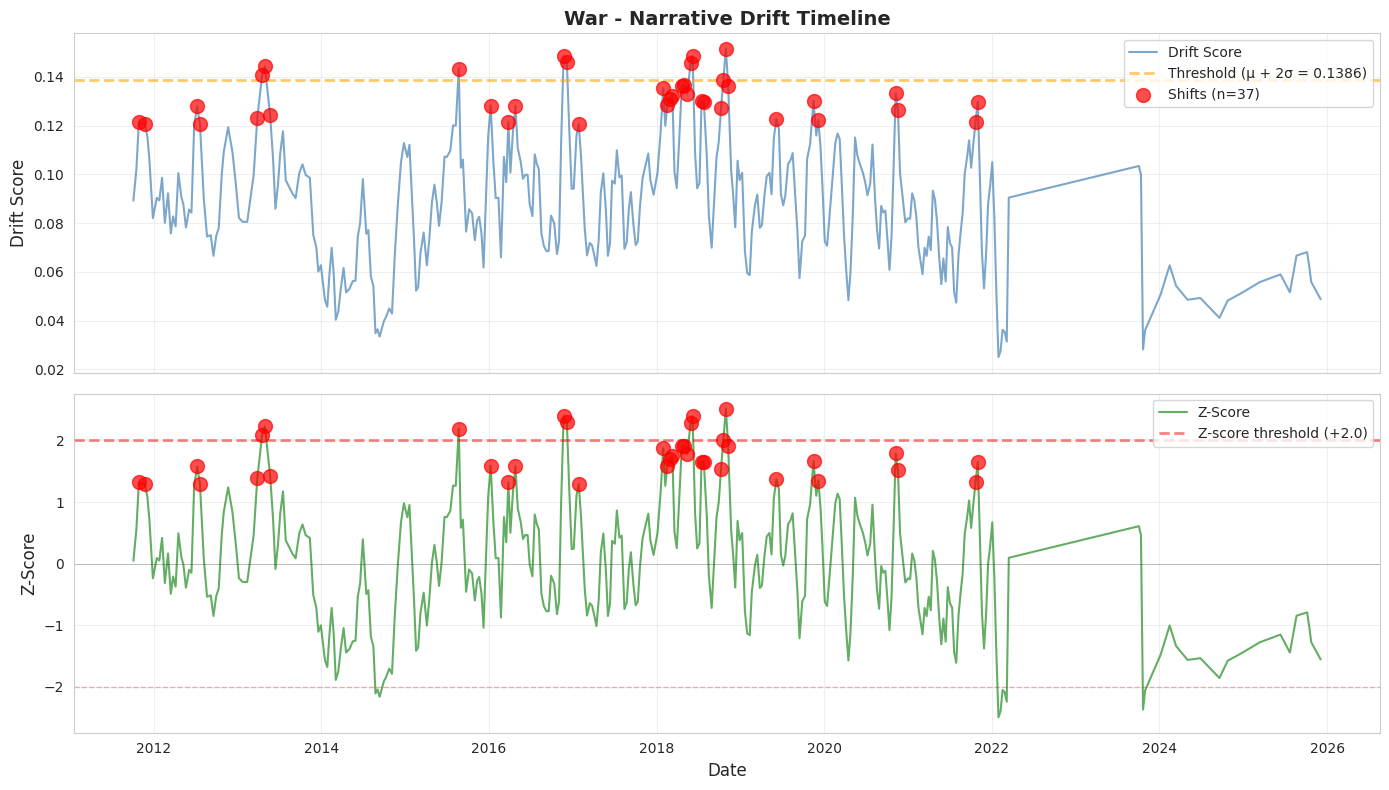

  ✅ Saved: /kaggle/working/drift_timeline_War.png

Plotting Health...


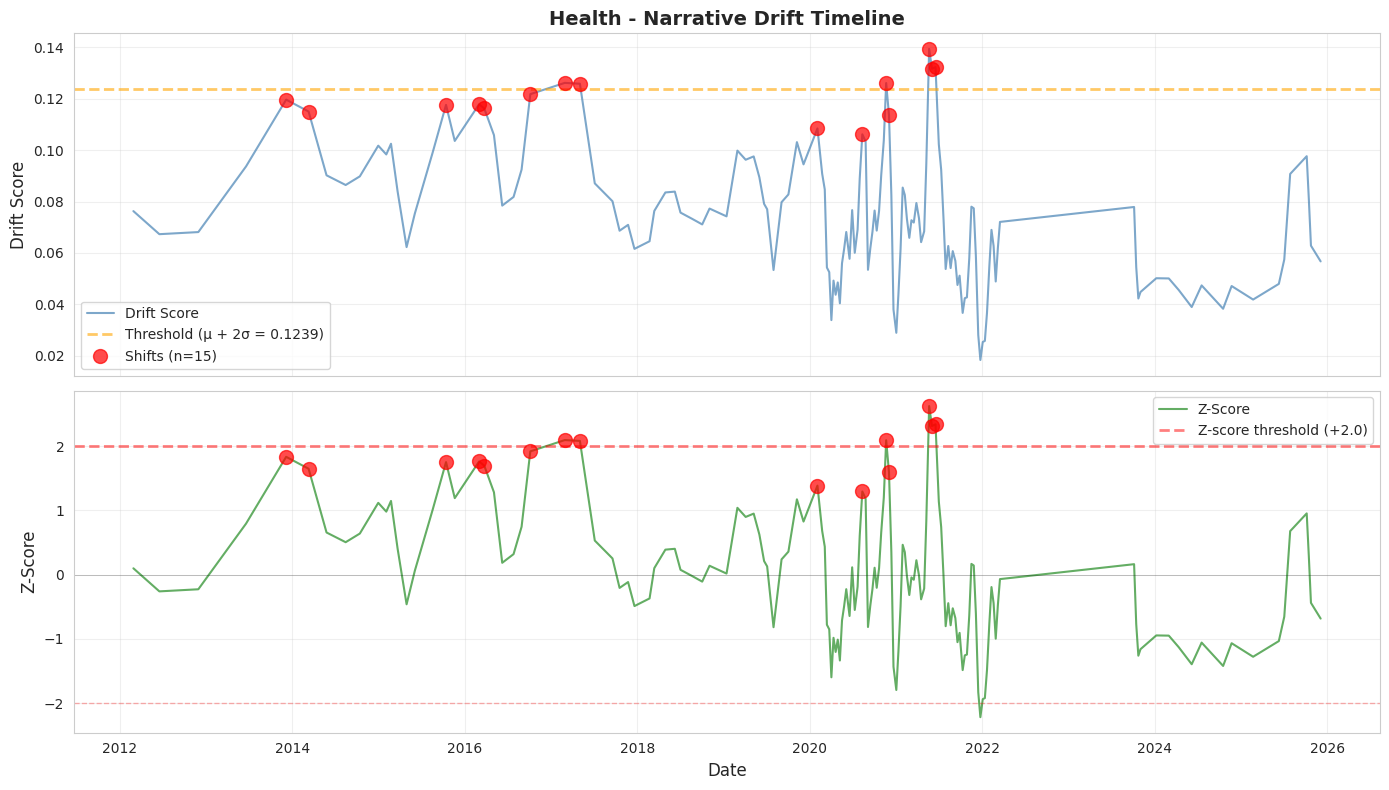

  ✅ Saved: /kaggle/working/drift_timeline_Health.png

Plotting Economics...


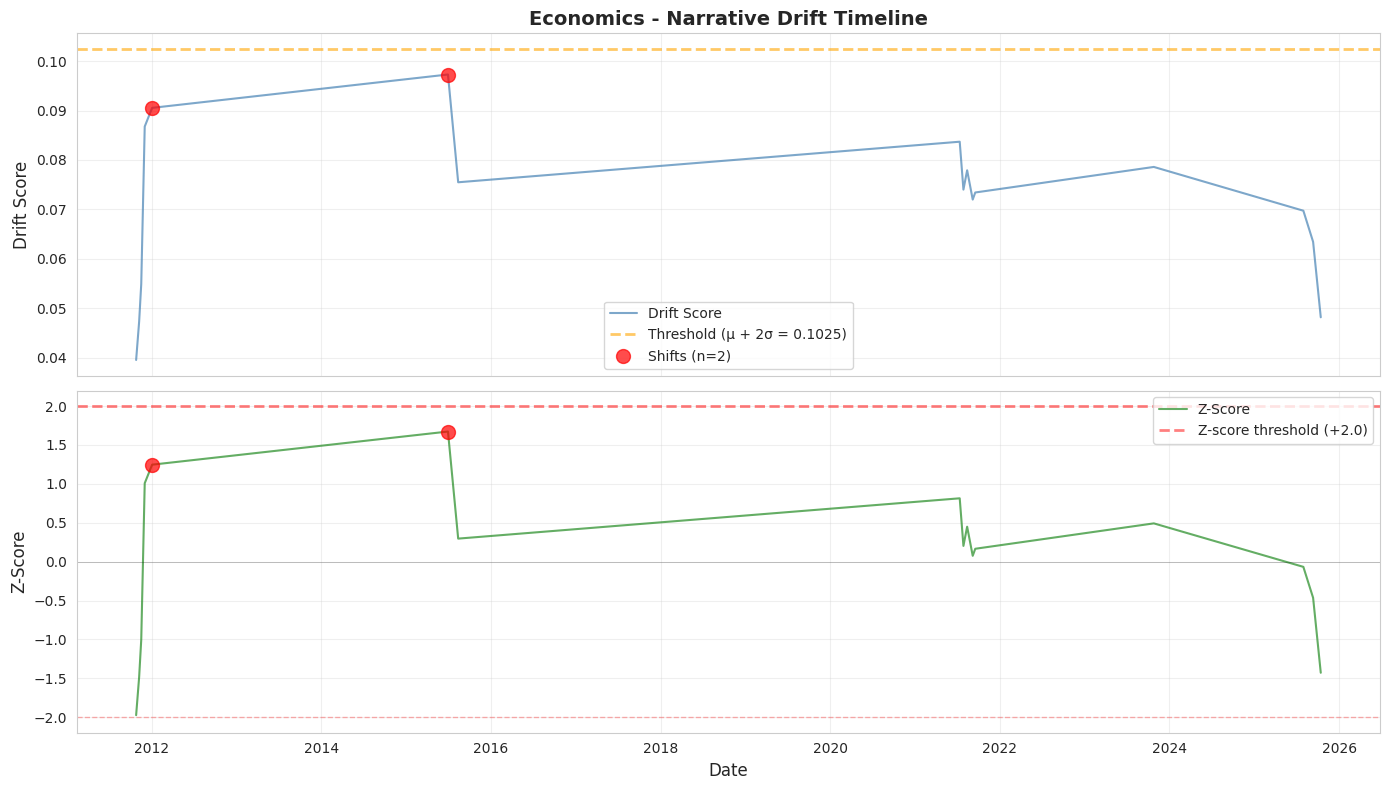

  ✅ Saved: /kaggle/working/drift_timeline_Economics.png

Plotting Technology...


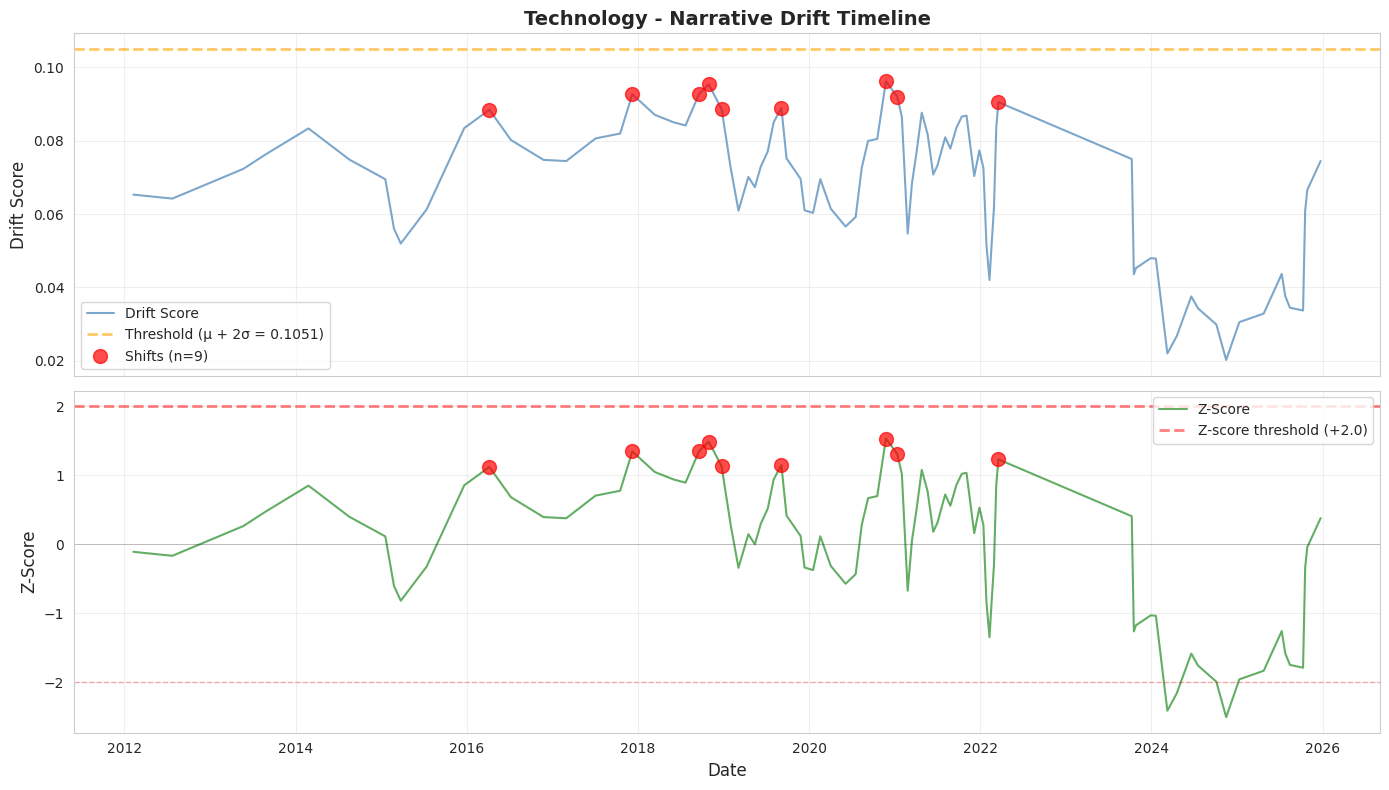

  ✅ Saved: /kaggle/working/drift_timeline_Technology.png

Plotting Climate...


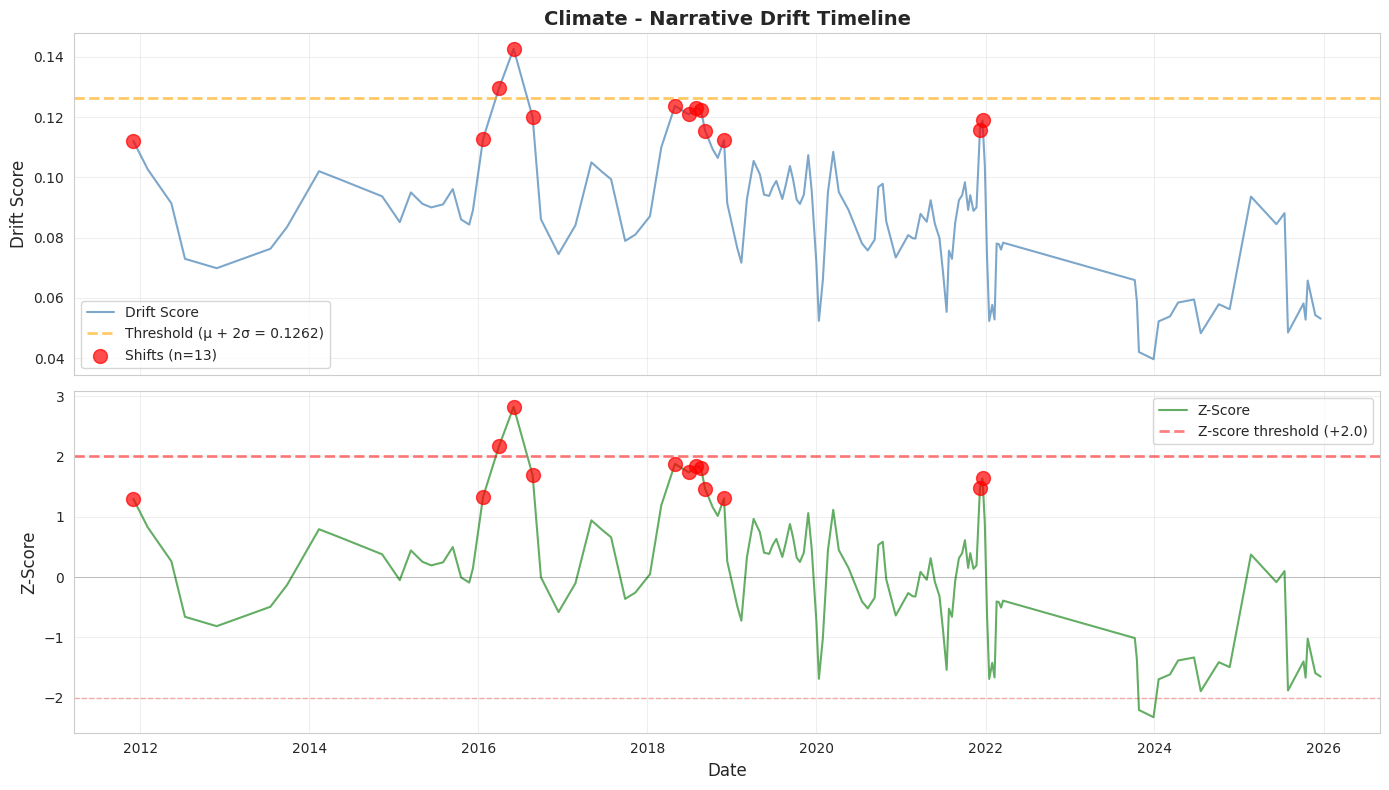

  ✅ Saved: /kaggle/working/drift_timeline_Climate.png

✅ Visualizations complete with dual subplot design and threshold lines


In [34]:
# Create enhanced topic-wise drift plots with DUAL SUBPLOTS and threshold lines
def plot_drift_timeline(drift_data, shifts, topic_name, config):
    """
    Plot drift timeline with detected shifts using DUAL SUBPLOT design.
    
    IMPROVEMENTS:
    - Separate plots for drift scores and z-scores
    - Clear threshold lines on both plots
    - Better visual separation
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    
    dates = [d['date'] for d in drift_data]
    drift_scores = [d['drift_score'] for d in drift_data]
    z_scores = [d['z_score'] for d in drift_data]
    
    # Compute threshold for drift scores
    drift_threshold = np.mean(drift_scores) + 2 * np.std(drift_scores)
    
    # Plot 1: Drift scores with threshold line
    ax1.plot(dates, drift_scores, alpha=0.7, linewidth=1.5, color='steelblue', label='Drift Score')
    
    # Add threshold line
    ax1.axhline(y=drift_threshold, color='orange', linestyle='--', alpha=0.6, 
                label=f'Threshold (μ + 2σ = {drift_threshold:.4f})', linewidth=2)
    
    ax1.set_ylabel('Drift Score', fontsize=12)
    ax1.set_title(f'{topic_name} - Narrative Drift Timeline', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # Mark shifts on drift plot
    if len(shifts) > 0:
        shift_dates = [s['date'] for s in shifts]
        shift_scores = [s['drift_score'] for s in shifts]
        ax1.scatter(shift_dates, shift_scores, color='red', s=100, 
                   marker='o', alpha=0.7, label=f'Shifts (n={len(shifts)})', zorder=5)
        ax1.legend()
    
    # Plot 2: Z-scores with threshold lines
    ax2.plot(dates, z_scores, alpha=0.7, linewidth=1.5, color='forestgreen', label='Z-Score')
    
    # Add threshold lines
    ax2.axhline(y=config.ZSCORE_THRESHOLD, color='red', linestyle='--', alpha=0.5, 
                label=f'Z-score threshold (+{config.ZSCORE_THRESHOLD})', linewidth=2)
    ax2.axhline(y=-config.ZSCORE_THRESHOLD, color='red', linestyle='--', alpha=0.3, linewidth=1)
    ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3, linewidth=0.5)
    
    ax2.set_ylabel('Z-Score', fontsize=12)
    ax2.set_xlabel('Date', fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    # Mark shifts on z-score plot
    if len(shifts) > 0:
        shift_z_scores = [s['z_score'] for s in shifts]
        ax2.scatter(shift_dates, shift_z_scores, color='red', s=100, 
                   marker='o', alpha=0.7, zorder=5)
    
    plt.tight_layout()
    
    # Save
    filepath = os.path.join(config.OUTPUT_PATH, f'drift_timeline_{topic_name}.png')
    plt.savefig(filepath, dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"  ✅ Saved: {filepath}")


# Plot for all topics
print("\n" + "="*60)
print("DRIFT TIMELINE VISUALIZATIONS")
print("="*60)

for topic_name in config.TOPICS:
    print(f"\nPlotting {topic_name}...")
    plot_drift_timeline(
        topic_drift_data[topic_name],
        topic_shifts[topic_name],
        topic_name,
        config
    )

print("\n" + "="*60)
print("✅ Visualizations complete with dual subplot design and threshold lines")
print("="*60)

---
# Stage 12: Topic-Wise Drift Visualization

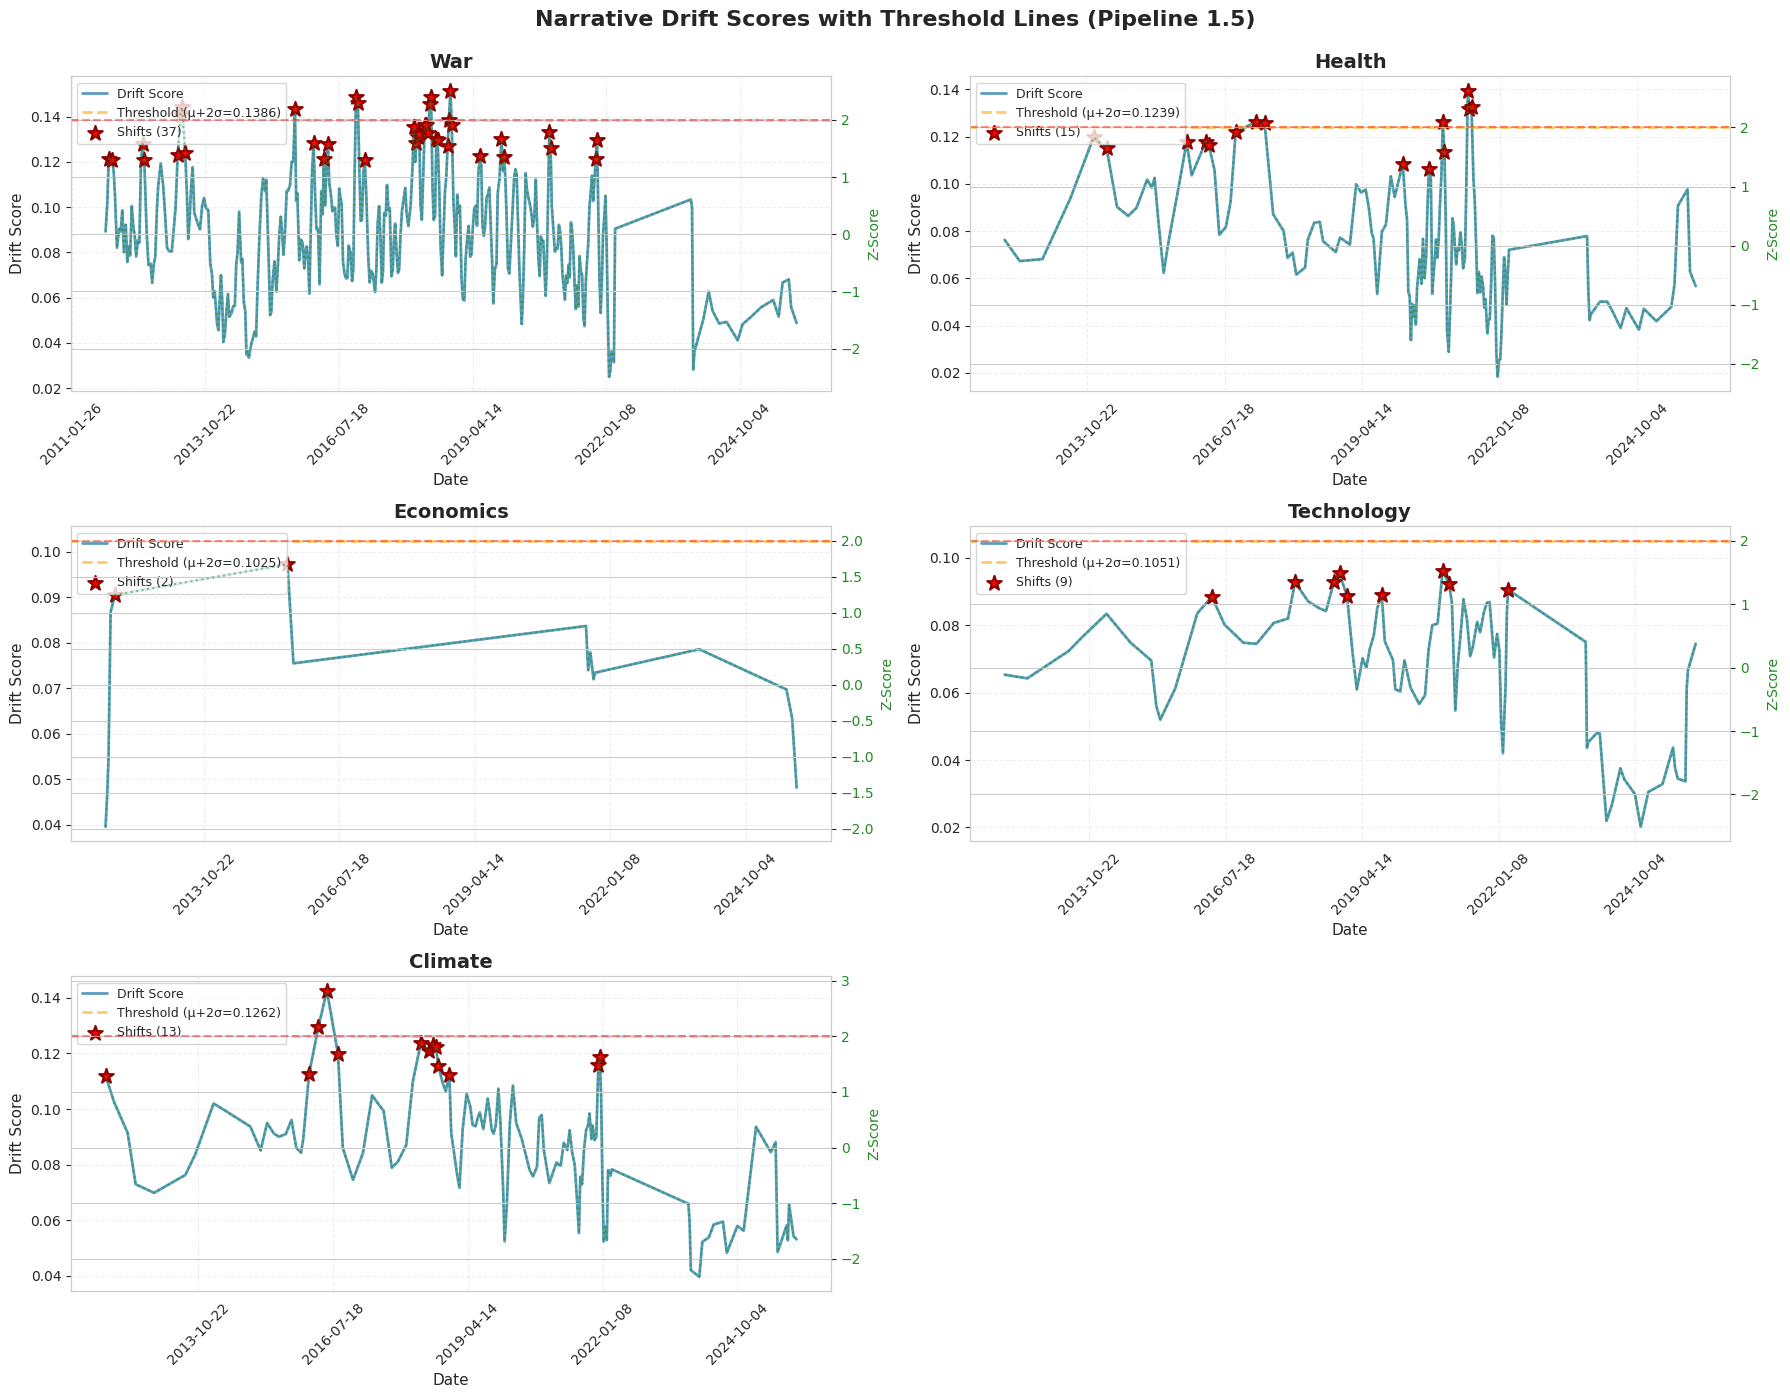


✅ Enhanced drift visualization saved with threshold lines
   Location: /kaggle/working/drift_scores_all_topics.png


In [20]:
# Create enhanced topic-wise drift plots with threshold lines
fig, axes = plt.subplots(3, 2, figsize=(18, 14))
axes = axes.flatten()

for idx, topic_name in enumerate(config.TOPICS):
    drift_data = topic_drift_data[topic_name]
    shifts = topic_shifts[topic_name]
    
    if len(drift_data) == 0:
        continue
    
    # Extract data
    dates = [d['date'] for d in drift_data]
    drift_scores = [d['drift_score'] for d in drift_data]
    z_scores = [d['z_score'] for d in drift_data]
    
    ax = axes[idx]
    
    # Compute thresholds
    drift_threshold = np.mean(drift_scores) + 2 * np.std(drift_scores)
    
    # Plot drift scores
    ax.plot(dates, drift_scores, linewidth=2, color='#2E86AB', label='Drift Score', alpha=0.8)
    
    # Add threshold line
    ax.axhline(y=drift_threshold, color='orange', linestyle='--', alpha=0.6,
              label=f'Threshold (μ+2σ={drift_threshold:.4f})', linewidth=2)
    
    # Add z-score=2 reference (on secondary axis)
    ax2 = ax.twinx()
    ax2.plot(dates, z_scores, linewidth=1.5, color='forestgreen', alpha=0.5, linestyle=':', label='Z-Score')
    ax2.axhline(y=config.ZSCORE_THRESHOLD, color='red', linestyle='--', alpha=0.4, linewidth=1.5)
    ax2.set_ylabel('Z-Score', fontsize=10, color='forestgreen')
    ax2.tick_params(axis='y', labelcolor='forestgreen')
    
    # Mark shifts
    if len(shifts) > 0:
        shift_dates = [s['date'] for s in shifts]
        shift_scores = [s['drift_score'] for s in shifts]
        ax.scatter(shift_dates, shift_scores, color='red', s=120,
                  marker='*', zorder=5, label=f'Shifts ({len(shifts)})', edgecolors='darkred', linewidths=1.5)
    
    # Styling
    ax.set_title(f'{topic_name}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Date', fontsize=11)
    ax.set_ylabel('Drift Score', fontsize=11)
    ax.grid(alpha=0.3, linestyle='--')
    ax.legend(loc='upper left', fontsize=9)
    ax.tick_params(axis='x', rotation=45)
    
    # Format x-axis
    ax.xaxis.set_major_locator(plt.MaxNLocator(6))

# Remove empty subplot
fig.delaxes(axes[5])

plt.suptitle('Narrative Drift Scores with Threshold Lines (Pipeline 1.5)',
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(os.path.join(config.OUTPUT_PATH, 'drift_scores_all_topics.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Enhanced drift visualization saved with threshold lines")
print(f"   Location: {config.OUTPUT_PATH}/drift_scores_all_topics.png")

---
# Stage 13: Summary Statistics

In [21]:
# Compute summary statistics
summary = {
    'total_days': sum(len(pools) for pools in topic_day_pools.values()),
    'total_groups': sum(len(groups) for groups in topic_groups.values()),
    'total_windows': sum(len(windows) for windows in topic_windows.values()),
    'total_shifts': sum(len(shifts) for shifts in topic_shifts.values()),
    'topics': {}
}

for topic_name in config.TOPICS:
    summary['topics'][topic_name] = {
        'days': len(topic_day_pools[topic_name]),
        'groups': len(topic_groups[topic_name]),
        'windows': len(topic_windows[topic_name]),
        'shifts': len(topic_shifts[topic_name])
    }

# Print summary
print("\n" + "="*60)
print("PIPELINE 1.5 SUMMARY")
print("="*60)

print(f"\n📊 Overall Statistics:")
print(f"  Total days: {summary['total_days']:,}")
print(f"  Total groups: {summary['total_groups']:,}")
print(f"  Total windows: {summary['total_windows']:,}")
print(f"  Total shifts detected: {summary['total_shifts']:,}")

print(f"\n📈 Per-Topic Breakdown:")
for topic_name in config.TOPICS:
    stats = summary['topics'][topic_name]
    print(f"\n  {topic_name}:")
    print(f"    Days: {stats['days']}")
    print(f"    Groups: {stats['groups']}")
    print(f"    Windows: {stats['windows']}")
    print(f"    Shifts: {stats['shifts']}")

print(f"\n🎯 Grouping Strategy:")
if config.USE_FIXED_GROUP_SIZE:
    print(f"  Approach 1: Fixed Group Size = {config.FIXED_GROUP_SIZE} days")
elif config.USE_MAX_DAY_GAP:
    print(f"  Approach 2: Max Day Gap = {config.MAX_DAY_GAP} days")

print(f"\n🪟 Window Configuration:")
print(f"  Window size: {config.WINDOW_SIZE} groups")
print(f"  Window stride: {config.WINDOW_STRIDE}")

print(f"\n💾 Outputs saved to: {config.OUTPUT_PATH}")
print(f"  - best_model.pt")
print(f"  - final_model.pt")
print(f"  - training_history.png")
print(f"  - evaluation_temporal_consistency.png")
print(f"  - drift_scores_all_topics.png")

print("\n" + "="*60)
print("✅ PIPELINE 1.5 COMPLETE")
print("="*60)

# Save summary to JSON
with open(os.path.join(config.OUTPUT_PATH, 'pipeline_summary.json'), 'w') as f:
    json.dump(summary, f, indent=2, default=str)

print(f"\n✅ Summary saved to: {config.OUTPUT_PATH}/pipeline_summary.json")


PIPELINE 1.5 SUMMARY

📊 Overall Statistics:
  Total days: 6,725
  Total groups: 2,244
  Total windows: 748
  Total shifts detected: 76

📈 Per-Topic Breakdown:

  War:
    Days: 3302
    Groups: 1101
    Windows: 367
    Shifts: 37

  Health:
    Days: 1339
    Groups: 447
    Windows: 149
    Shifts: 15

  Economics:
    Days: 152
    Groups: 51
    Windows: 17
    Shifts: 2

  Technology:
    Days: 800
    Groups: 267
    Windows: 89
    Shifts: 9

  Climate:
    Days: 1132
    Groups: 378
    Windows: 126
    Shifts: 13

🎯 Grouping Strategy:
  Approach 1: Fixed Group Size = 3 days

🪟 Window Configuration:
  Window size: 3 groups
  Window stride: 3

💾 Outputs saved to: /kaggle/working
  - best_model.pt
  - final_model.pt
  - training_history.png
  - evaluation_temporal_consistency.png
  - drift_scores_all_topics.png

✅ PIPELINE 1.5 COMPLETE

✅ Summary saved to: /kaggle/working/pipeline_summary.json
